In [4]:
import pandas as pd
df= pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [12]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [13]:
df.drop("customerID", axis=1, inplace=True)

In [14]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [15]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [16]:
df.dropna(inplace=True)

In [17]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [18]:
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]

for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})

In [19]:
df["MultipleLines"] = df["MultipleLines"].replace("No phone service", "No")

In [20]:
cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
        "TechSupport", "StreamingTV", "StreamingMovies"]

for col in cols:
    df[col] = df[col].replace("No internet service", "No")

In [21]:
df = pd.get_dummies(df, drop_first=True)

In [22]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   Partner                                7032 non-null   int64  
 2   Dependents                             7032 non-null   int64  
 3   tenure                                 7032 non-null   int64  
 4   PhoneService                           7032 non-null   int64  
 5   PaperlessBilling                       7032 non-null   int64  
 6   MonthlyCharges                         7032 non-null   float64
 7   TotalCharges                           7032 non-null   float64
 8   Churn                                  7032 non-null   int64  
 9   gender_Male                            7032 non-null   bool   
 10  MultipleLines_Yes                      7032 non-null   bool   
 11  InternetS

,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
PaperlessBilling,0
MonthlyCharges,0
TotalCharges,0
Churn,0
gender_Male,0


In [23]:
df.head(2)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,False,...,True,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,True,...,False,True,False,False,False,True,False,False,False,True


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   Partner                                7032 non-null   int64  
 2   Dependents                             7032 non-null   int64  
 3   tenure                                 7032 non-null   int64  
 4   PhoneService                           7032 non-null   int64  
 5   PaperlessBilling                       7032 non-null   int64  
 6   MonthlyCharges                         7032 non-null   float64
 7   TotalCharges                           7032 non-null   float64
 8   Churn                                  7032 non-null   int64  
 9   gender_Male                            7032 non-null   bool   
 10  MultipleLines_Yes                      7032 non-null   bool   
 11  InternetS

In [25]:
bool_cols = df.select_dtypes(include=['bool']).columns

for col in bool_cols:
    df[col] = df[col].astype(int)

In [26]:
df.to_csv("cleaned_telco_churn.csv", index=False)

In [27]:
df["Churn"].value_counts()

,count
Churn,
0,5163
1,1869


In [28]:
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
0,0.734215
1,0.265785


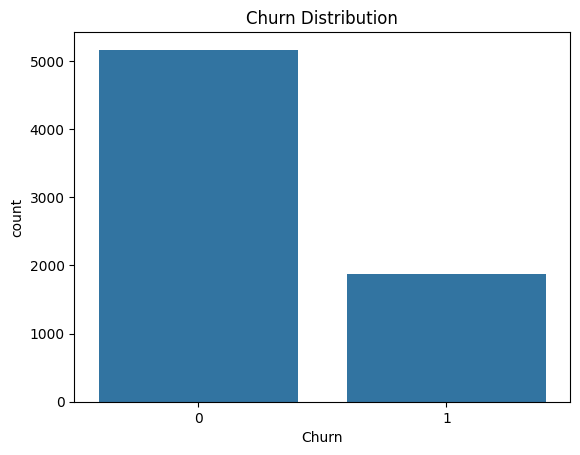

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

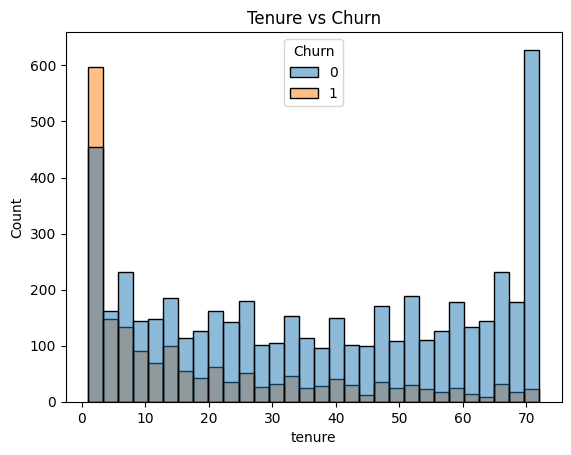

In [30]:
sns.histplot(data=df, x="tenure", hue="Churn", bins=30)
plt.title("Tenure vs Churn")
plt.show()

In [33]:

df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
0,37.650010
1,17.979133


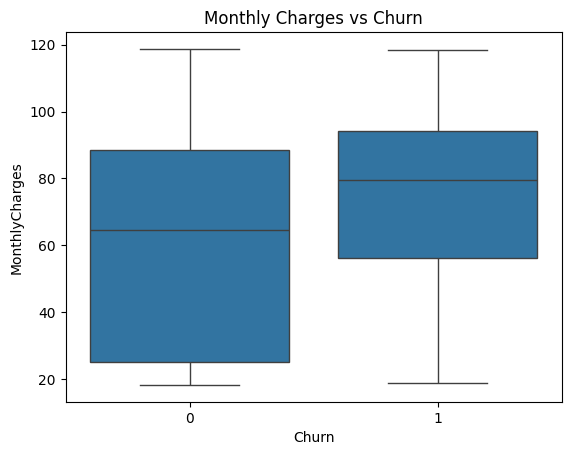

In [34]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

In [35]:
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
0,61.307408
1,74.441332


In [36]:
df["charge_group"] = pd.cut(df["MonthlyCharges"], bins=5)

df.groupby("charge_group")["Churn"].mean()

/tmp/ipykernel_723/375548613.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("charge_group")["Churn"].mean()


,Churn
charge_group,
"(18.15, 38.35]",0.114461
"(38.35, 58.45]",0.270189
"(58.45, 78.55]",0.295238
"(78.55, 98.65]",0.369863
"(98.65, 118.75]",0.300573


In [37]:
import pandas as pd

# Create a dictionary to hold EDA summary
eda_summary = {}

# 1️⃣ Churn distribution
eda_summary['churn_count'] = df['Churn'].value_counts().to_dict()
eda_summary['churn_percentage'] = (df['Churn'].value_counts(normalize=True) * 100).to_dict()

# 2️⃣ Tenure vs Churn
eda_summary['tenure_stats_by_churn'] = df.groupby('Churn')['tenure'].describe().to_dict()
eda_summary['tenure_mean_by_churn'] = df.groupby('Churn')['tenure'].mean().to_dict()

# 3️⃣ Monthly Charges vs Churn
eda_summary['monthly_charges_stats_by_churn'] = df.groupby('Churn')['MonthlyCharges'].describe().to_dict()
eda_summary['monthly_charges_mean_by_churn'] = df.groupby('Churn')['MonthlyCharges'].mean().to_dict()

# 4️⃣ Churn by charge range
eda_summary['churn_by_charge_group'] = df.groupby('charge_group')['Churn'].mean().to_dict()

# Convert dictionary to DataFrame for saving
summary_df = pd.DataFrame.from_dict(eda_summary, orient='index')
summary_df = summary_df.transpose()  # transpose to make it readable

# Save as CSV
summary_df.to_csv("EDA_summary.csv", index=True)

/tmp/ipykernel_723/2561824824.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eda_summary['churn_by_charge_group'] = df.groupby('charge_group')['Churn'].mean().to_dict()


In [39]:
# Tenure bins (0-12, 12-24, 24-48, 48-72 months)
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72], labels=False)

# MonthlyCharges bins (we can use same as your previous charge_group)
df['charge_group'] = pd.cut(df['MonthlyCharges'], bins=[0, 20, 40, 60, 80, 100, 120], labels=False)

In [40]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [41]:
# High Monthly Charges + Month-to-month contract
df['HighCharge_MonthToMonth'] = ((df['MonthlyCharges'] > 0.6) & (df['Contract_One year']==0) & (df['Contract_Two year']==0)).astype(int)

In [42]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   Partner                                7032 non-null   int64  
 2   Dependents                             7032 non-null   int64  
 3   tenure                                 7032 non-null   float64
 4   PhoneService                           7032 non-null   int64  
 5   PaperlessBilling                       7032 non-null   int64  
 6   MonthlyCharges                         7032 non-null   float64
 7   TotalCharges                           7032 non-null   float64
 8   Churn                                  7032 non-null   int64  
 9   gender_Male                            7032 non-null   int64  
 10  MultipleLines_Yes                      7032 non-null   int64  
 11  InternetS

,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
PaperlessBilling,0
MonthlyCharges,0
TotalCharges,0
Churn,0
gender_Male,0


In [43]:
# Save FE dataset
df.to_csv("Telco_Churn_FE.csv", index=False)

In [44]:
from sklearn.model_selection import train_test_split

# 1️⃣ Separate features and target
X = df.drop("Churn", axis=1)  # all columns except target
y = df["Churn"]               # target column

# 2️⃣ Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3️⃣ Check sizes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))

X_train shape: (5625, 26)
X_test shape: (1407, 26)
y_train distribution:
 Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64
y_test distribution:
 Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


In [45]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# 1️⃣ Initialize model
log_model = LogisticRegression(max_iter=1000, random_state=42)

# 2️⃣ Train
log_model.fit(X_train, y_train)

# 3️⃣ Predict
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

# 4️⃣ Evaluate
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print(classification_report(y_test, y_pred_log))

# 5️⃣ Save predictions
log_preds = X_test.copy()
log_preds["Actual"] = y_test
log_preds["Predicted"] = y_pred_log
log_preds["Churn_Probability"] = y_prob_log
log_preds.to_csv("LogisticRegression_Predictions.csv", index=False)

Logistic Regression Accuracy: 0.798862828713575
Logistic Regression ROC-AUC: 0.8337159822126511
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



In [46]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

# 1️⃣ Initialize model
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

# 2️⃣ Train
rf_model.fit(X_train, y_train)

# 3️⃣ Predict
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# 4️⃣ Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

# 5️⃣ Save predictions
rf_preds = X_test.copy()
rf_preds["Actual"] = y_test
rf_preds["Predicted"] = y_pred_rf
rf_preds["Churn_Probability"] = y_prob_rf
rf_preds.to_csv("RandomForest_Predictions.csv", index=False)

Random Forest Accuracy: 0.7896233120113717
Random Forest ROC-AUC: 0.8192314063705214
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [47]:
# XGBoost
!pip install xgboost -q
from xgboost import XGBClassifier

# 1️⃣ Initialize model
xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42, use_label_encoder=False, eval_metric='logloss')

# 2️⃣ Train
xgb_model.fit(X_train, y_train)

# 3️⃣ Predict
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

# 4️⃣ Evaluate
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print(classification_report(y_test, y_pred_xgb))

# 5️⃣ Save predictions
xgb_preds = X_test.copy()
xgb_preds["Actual"] = y_test
xgb_preds["Predicted"] = y_pred_xgb
xgb_preds["Churn_Probability"] = y_prob_xgb
xgb_preds.to_csv("XGBoost_Predictions.csv", index=False)

XGBoost Accuracy: 0.7846481876332623
XGBoost ROC-AUC: 0.832195308819647
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.61      0.53      0.57       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.78      0.78      0.78      1407



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:37:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [48]:
# LightGBM
!pip install lightgbm -q
import lightgbm as lgb

# 1️⃣ Initialize model
lgb_model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1, random_state=42)

# 2️⃣ Train
lgb_model.fit(X_train, y_train)

# 3️⃣ Predict
y_pred_lgb = lgb_model.predict(X_test)
y_prob_lgb = lgb_model.predict_proba(X_test)[:,1]

# 4️⃣ Evaluate
print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgb))
print("LightGBM ROC-AUC:", roc_auc_score(y_test, y_prob_lgb))
print(classification_report(y_test, y_pred_lgb))

# 5️⃣ Save predictions
lgb_preds = X_test.copy()
lgb_preds["Actual"] = y_test
lgb_preds["Predicted"] = y_pred_lgb
lgb_preds["Churn_Probability"] = y_prob_lgb
lgb_preds.to_csv("LightGBM_Predictions.csv", index=False)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001046 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 634
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265778 -> initscore=-1.016151
[LightGBM] [Info] Start training from score -1.016151
LightGBM Accuracy: 0.7725657427149965
LightGBM ROC-AUC: 0.8191045757385944
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1033
           1       0.58      0.52      0.55       374

    accuracy                           0.77      1407
   macro avg       0.71      0.69      0.70      1407
weighted avg       

In [49]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score

# List of models and predictions
models = {
    "Logistic Regression": (y_test, y_pred_log, y_prob_log),
    "Random Forest": (y_test, y_pred_rf, y_prob_rf),
    "XGBoost": (y_test, y_pred_xgb, y_prob_xgb),
    "LightGBM": (y_test, y_pred_lgb, y_prob_lgb)
}

# Initialize summary
summary = []

for name, (y_t, y_p, y_prob) in models.items():
    summary.append({
        "Model": name,
        "Accuracy": accuracy_score(y_t, y_p),
        "ROC-AUC": roc_auc_score(y_t, y_prob),
        "Precision (churn)": precision_score(y_t, y_p, pos_label=1),
        "Recall (churn)": recall_score(y_t, y_p, pos_label=1),
        "F1 (churn)": f1_score(y_t, y_p, pos_label=1)
    })

# Convert to DataFrame
summary_df = pd.DataFrame(summary)
summary_df

,Model,Accuracy,ROC-AUC,Precision (churn),Recall (churn),F1 (churn)
0,Logistic Regression,0.798863,0.833716,0.641745,0.550802,0.592806
1,Random Forest,0.789623,0.819231,0.628289,0.510695,0.563422
2,XGBoost,0.784648,0.832195,0.607903,0.534759,0.568990
3,LightGBM,0.772566,0.819105,0.580357,0.521390,0.549296


In [50]:
summary_df.to_csv("Model_Comparison.csv", index=False)

In [51]:
import pickle

# Save Logistic Regression model
best_model = log_model  # Logistic Regression
with open("Best_Churn_Model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("✅ Logistic Regression saved as Best_Churn_Model.pkl")

✅ Logistic Regression saved as Best_Churn_Model.pkl


In [52]:
import pandas as pd
import numpy as np

# Get coefficients
coeff_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": best_model.coef_[0]
})

# Sort by absolute value
coeff_df["Abs_Coefficient"] = np.abs(coeff_df["Coefficient"])
coeff_df = coeff_df.sort_values(by="Abs_Coefficient", ascending=False)

coeff_df.head(10)  # Top 10 features

,Feature,Coefficient,Abs_Coefficient
3,tenure,-2.069794,2.069794
19,Contract_Two year,-1.530948,1.530948
7,TotalCharges,1.064763,1.064763
10,InternetService_Fiber optic,0.937601,0.937601
18,Contract_One year,-0.851925,0.851925
11,InternetService_No,-0.797099,0.797099
4,PhoneService,-0.534499,0.534499
12,OnlineSecurity_Yes,-0.411131,0.411131
21,PaymentMethod_Electronic check,0.398708,0.398708
15,TechSupport_Yes,-0.362914,0.362914


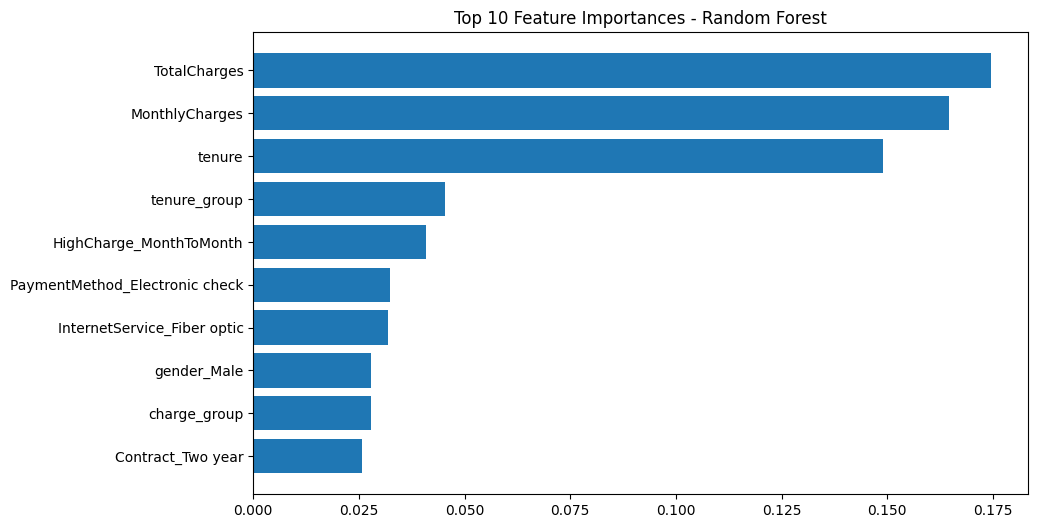

In [53]:
# Example with Random Forest
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
feat_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_df["Feature"][:10][::-1], feat_df["Importance"][:10][::-1])
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

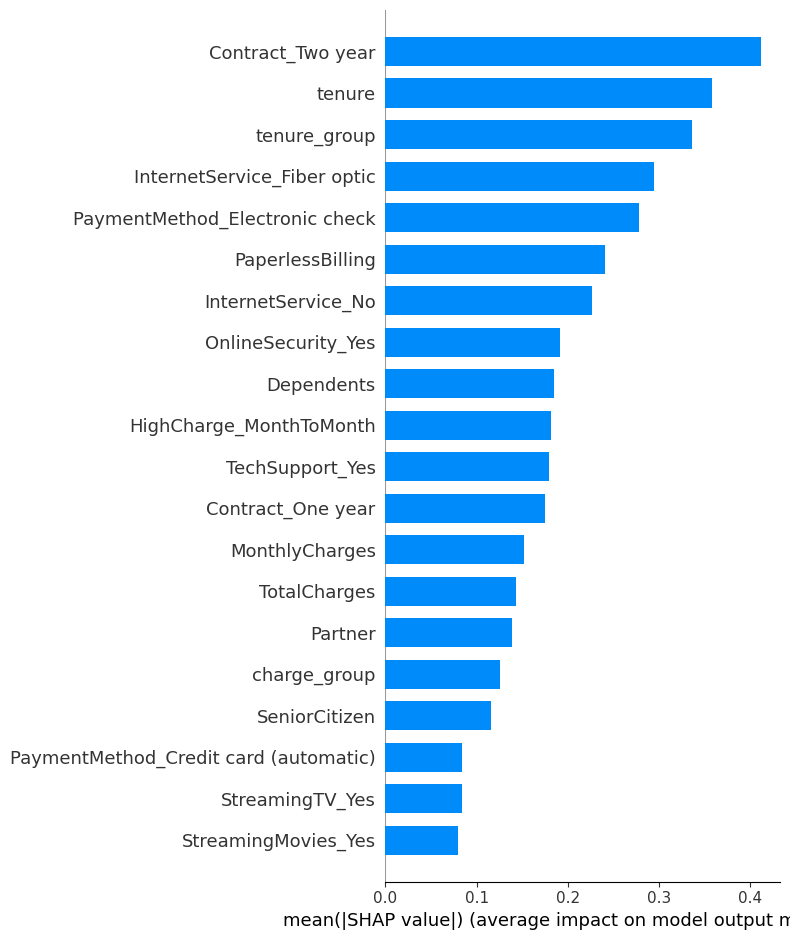

In [54]:
!pip install shap -q
import shap

# Use model (Logistic Regression)
explainer = shap.LinearExplainer(best_model, X_train, feature_perturbation="correlation_dependent")
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [55]:
import pandas as pd
import shap

# Assuming shap_values and X_test are already defined
# shap_values: array of SHAP values for each sample

# Convert to DataFrame
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)

# Calculate mean absolute SHAP value for each feature
shap_summary = pd.DataFrame({
    "Feature": shap_df.columns,
    "Mean_Abs_SHAP": shap_df.abs().mean().values
}).sort_values(by="Mean_Abs_SHAP", ascending=False)

# Display top 10 features
shap_summary.head(10)

,Feature,Mean_Abs_SHAP
19,Contract_Two year,0.412274
3,tenure,0.358105
24,tenure_group,0.336693
10,InternetService_Fiber optic,0.294674
21,PaymentMethod_Electronic check,0.277919
5,PaperlessBilling,0.241274
11,InternetService_No,0.226705
12,OnlineSecurity_Yes,0.191943
2,Dependents,0.184759
25,HighCharge_MonthToMonth,0.182098


In [56]:
shap_summary.to_csv("SHAP_Feature_Importance.csv", index=False)

In [57]:
# Example using Logistic Regression (best model)
customer_probs = best_model.predict_proba(X_test)[:,1]  # probability of churn (class 1)

# Create a table with predictions
churn_pred_df = X_test.copy()
churn_pred_df["Churn_Probability"] = customer_probs
churn_pred_df["Predicted_Churn"] = (customer_probs > 0.5).astype(int)  # optional Yes/No prediction

# Display top 10 risky customers
churn_pred_df.sort_values(by="Churn_Probability", ascending=False).head(10)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,gender_Male,MultipleLines_Yes,...,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,charge_group,tenure_group,HighCharge_MonthToMonth,Churn_Probability,Predicted_Churn
3380,1,1,0,0.000000,1,1,0.764677,0.008805,1,1,...,0,0,0,1,0,4,0,1,0.854403,1
3159,1,0,0,0.028169,1,1,0.762189,0.036574,1,1,...,0,0,0,1,0,4,0,1,0.854061,1
2631,1,1,0,0.084507,1,1,0.805970,0.074619,1,1,...,0,0,0,1,0,4,0,1,0.846258,1
3727,0,0,0,0.028169,1,1,0.779602,0.031514,0,1,...,0,0,0,1,0,4,0,1,0.830872,1
2797,0,0,0,0.028169,1,1,0.822886,0.035905,1,1,...,0,0,0,1,0,5,0,1,0.829209,1
582,1,0,0,0.042254,1,1,0.705970,0.037780,0,1,...,0,0,0,1,0,4,0,1,0.819917,1
4585,1,0,0,0.000000,1,1,0.664677,0.007645,0,1,...,0,0,0,1,0,4,0,1,0.818314,1
6839,0,0,0,0.140845,1,1,0.820896,0.128196,0,1,...,0,0,0,1,0,5,0,1,0.812847,1
933,1,0,0,0.042254,1,1,0.660199,0.039384,0,1,...,0,0,0,1,0,4,0,1,0.810176,1
6574,1,0,0,0.112676,1,1,0.714925,0.092084,0,1,...,0,0,0,1,0,4,0,1,0.806612,1


In [61]:
churn_pred_df.to_csv("Customer_Churn_Probabilities.csv", index=False)

In [63]:
# Cell 1: Install Streamlit and ngrok
!pip install streamlit -q
!pip install pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 43.6 MB/s eta 0:00:00


In [64]:
# Cell 2: Write Streamlit dashboard script
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import shap

# Load trained model
with open("Best_Churn_Model.pkl", "rb") as f:
    model = pickle.load(f)

st.title("Customer Churn Prediction Dashboard")
st.write("Enter customer details to predict churn probability.")

# User Inputs
customer_name = st.text_input("Customer Name")
customer_id = st.text_input("Customer ID")
tenure = st.number_input("Tenure (months)", min_value=0, max_value=100)
monthly_charges = st.number_input("Monthly Charges", min_value=0.0, max_value=1000.0)
contract = st.selectbox("Contract Type", ["Month-to-month", "One year", "Two year"])
internet_service = st.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])
tech_support = st.selectbox("Tech Support", ["Yes", "No"])
online_security = st.selectbox("Online Security", ["Yes", "No"])

# Convert inputs into model-ready dataframe
input_df = pd.DataFrame({
    "tenure": [tenure],
    "MonthlyCharges": [monthly_charges],
    "Contract_Month-to-month": [1 if contract=="Month-to-month" else 0],
    "Contract_One year": [1 if contract=="One year" else 0],
    "Contract_Two year": [1 if contract=="Two year" else 0],
    "InternetService_DSL": [1 if internet_service=="DSL" else 0],
    "InternetService_Fiber optic": [1 if internet_service=="Fiber optic" else 0],
    "InternetService_No": [1 if internet_service=="No" else 0],
    "TechSupport_Yes": [1 if tech_support=="Yes" else 0],
    "OnlineSecurity_Yes": [1 if online_security=="Yes" else 0]
})

# Predict churn probability
if st.button("Predict Churn"):
    prob = model.predict_proba(input_df)[:,1][0]
    predicted = "Yes" if prob>0.5 else "No"

    st.success(f"Customer {customer_name} (ID: {customer_id})")
    st.write(f"Churn Probability: {prob:.2f}")
    st.write(f"Predicted Churn: {predicted}")

    # Optional: SHAP explanation
    explainer = shap.LinearExplainer(model, input_df)
    shap_values = explainer.shap_values(input_df)
    shap_df = pd.DataFrame({
        "Feature": input_df.columns,
        "SHAP_Value": shap_values[0]
    }).sort_values(by="SHAP_Value", key=abs, ascending=False)

    st.write("Top Contributing Features:")
    st.table(shap_df.head(3))

Writing app.py


In [ ]:
from pyngrok import ngrok


ngrok.set_auth_token("YOUR_AUTHTOKEN_HERE")